#**Instalación de face_recognition**

Esta instalación es necesaria inclus en Colab, ya que al tratar de ejecutar el proyecto no cargó la librería

In [32]:
!pip install face_recognition

#**RED NEURONAL SIAMESA PARA RECONICIMIENTO FACIAL**
Descripción:

Este proyecto implementa una aproximación funcional
de una Red Neuronal Siamesa para reconocimiento facial.

#IMPORTACIÓN DE LIBRERÍAS

In [33]:
import cv2
import numpy as npá
import face_recognition
import matplotlib.pyplot as plt
from google.colab import files

#FUNCIÓN PARA CARGA DE IMAGENES

In [34]:
def cargar_imagen(path):
  '''
  Carga de una imagen y extrae:

  - Imagen
  - Ubicación del rostro en la imagen
  - Codificación facial

  '''
  #------------------
  #Cargar Imagen
  #------------------

  image=face_recognition.load_image_file(path)


  #--------------------
  #Detección del rostro en la imagen
  #--------------------
  faces = face_recognition.face_locations(image)

  if len(faces) == 0:

    raise ValueError(
        f"No se detectó rostro en {path}"
    )

  #----------------------
  #Extracción de Embedding
  #----------------------
  encoding=face_recognition.face_encodings(image)[0]

  return image,faces[0],encoding







#FUNCIÓN QUE DIBUJA RECTANGULO EN ROSTRO

In [35]:
def dibujar_rostro(image, face):

    top, right, bottom, left = face

    cv2.rectangle(
        image,
        (left, top),
        (right, bottom),
        (255,0,255),
        2
    )

    return image

#SELECCIÓN DE LAS IMÁGENES

In [36]:
#----------------
#Primera Imagen
#----------------

uploaded1=files.upload()
image1_path=list(uploaded1.keys())[0]

#----------------
#Segunda Imagen
#----------------

uploades2=files.upload()
image2_path=list(uploades2.keys())[0]


Saving king.jpg to king.jpg


Saving king2.jpg to king2.jpg


#CARGA DE LAS IMÁGENES

In [37]:
print("===================================")
print("CARGANDO IMÁGENES")
print("===================================")

img1, face1, encode1 = cargar_imagen(
    image1_path
)

img2, face2, encode2 = cargar_imagen(
    image2_path
)

CARGANDO IMÁGENES


#COMPARACIÓN FACIAL

In [38]:
print("\n===================================")
print("COMPARANDO ROSTROS")
print("===================================")

resultado = face_recognition.compare_faces(
    [encode1],
    encode2
)


COMPARANDO ROSTROS


#DISTANCIA ENTRE EMBEDDINGS

In [39]:
distance = face_recognition.face_distance(
    [encode1],
    encode2
)

print("Distancia facial:", distance[0])

Distancia facial: 0.5460065517326872


#RESULTADO

In [40]:
print("\n===================================")
print("RESULTADO")
print("===================================")

if resultado[0]:

    mensaje = "SON LA MISMA PERSONA"

    print("Resultado:", mensaje)

else:

    mensaje = "SON PERSONAS DIFERENTES"

    print("Resultado:", mensaje)


RESULTADO
Resultado: SON LA MISMA PERSONA


#DIBUJAR LOS ROSTROS

In [41]:
img1 = dibujar_rostro(img1, face1)
img2 = dibujar_rostro(img2, face2)

#VISUALIZACIÓN

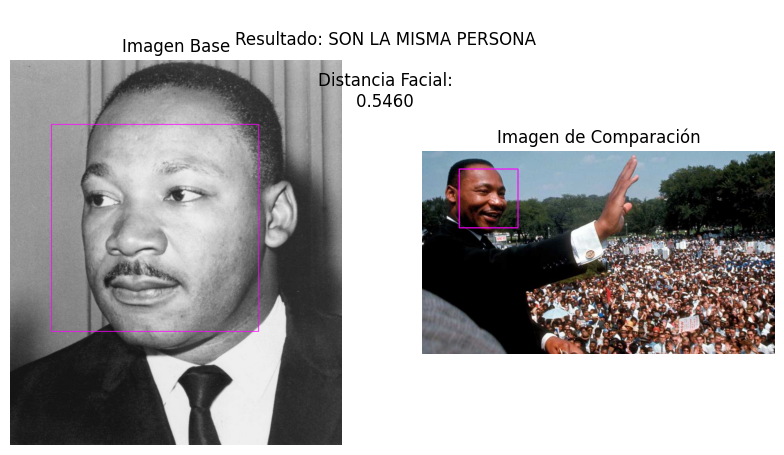

In [42]:
plt.figure(figsize=(10,5))

#---------------
#Primera Imagen
#---------------

plt.subplot(1,2,1)

plt.imshow(img1)

plt.title("Imagen Base")

plt.axis("off")

#---------------
#Segunda Imagen
#---------------

plt.subplot(1,2,2)

plt.imshow(img2)

plt.title("Imagen de Comparación")

plt.axis("off")

#---------------------
#Título General
#---------------------

plt.suptitle(
    f"""
    Resultado: {mensaje}

    Distancia Facial:
    {distance[0]:.4f}
    """
)

plt.show()